## Explore nested-EAGLE CONUS forecasts

The **nested-Experimental Artificial Intelligence Global and Limited-area Ensemble (nested-EAGLE)** is an experimental machine-learning weather forecast system developed through a joint effort between NOAA Research Laboratories, the Earth Prediction Innovation Center (EPIC), and the National Weather Service (NWS). Built with the ECMWF and partner agencies' Anemoi framework, it combines a 0.25-degree global model with a higher-resolution nested domain over the contiguous United States (CONUS).

This tutorial demonstrates how to discover nested-EAGLE CONUS forecast items in the Microsoft Planetary Computer STAC catalog, stream a signed remote netCDF asset with obstore and obspec-utils, transform the projected grid to longitude and latitude coordinates, select surface and pressure-level fields, create maps, and animate a forecast sequence with GeoGIF.

## Dataset at a glance

- **Coverage:** October 1, 2024 to present
- **CONUS grid:** 6 km resolution on the High-Resolution Rapid Refresh (HRRR) Lambert Conformal Conic (LCC) grid
- **Initialization:** Four cycles daily at 00, 06, 12, and 18 Z, typically available about six hours later
- **Forecast horizon:** 10 days (240 hours) at 6-hour intervals
- **Format:** One netCDF file per forecast, with 2D surface, 10 m, and 80 m fields plus 3D atmospheric fields on 12 pressure levels from 100 to 1000 hPa

The collection is provided free of charge on an unsupported, experimental basis. It should not be used for critical operational decisions.

**Producer:** NOAA EPIC  
**Host:** Microsoft Planetary Computer

**Citation:** The Earth Prediction Innovation Center (EPIC) and the NOAA AI for Numerical Weather Prediction (AI4NWP) Working Group. (2026). *The nested-EAGLE (Experimental AI Global and Limited-area Ensemble forecast system) v1.1.0*. Zenodo. [https://doi.org/10.5281/zenodo.19672026](https://doi.org/10.5281/zenodo.19672026)

Load required imports and set variables used throughout the rest of the notebook.

In [ ]:
%pip install pystac-client obstore obspec-utils geogif xarray "matplotlib<3.10" matplotlib-inline cartopy h5netcdf h5py dask

In [18]:
from datetime import datetime, timedelta, timezone

import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import geogif
import matplotlib.pyplot as plt
import numpy as np
import pyproj
import pystac_client
import xarray as xr
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure
from obspec_utils.readers import BlockStoreReader
from obstore.store import HTTPStore

# chose forecasts you wish to load
# code will filter stac item search to initializations between start and stop
init_start = "2025-01-31T18:00:00"
init_stop = "2025-02-02T18:00:00"

# chose forecast and the amount of lead time you wish to plot.
init_to_plot = datetime(2025, 1, 31, 18, tzinfo=timezone.utc)
# easy-to-edit lead times
forecast_start_lead = timedelta(hours=0)  # set to 0 to start with initial conditions
forecast_stop_lead = timedelta(hours=240)  # complete forecast horizon

variables_to_load = [
    "2m_temperature",
    "total_precipitation_6hr",
    "meridional_wind",
    "crs",  # required for loading lat/lon info later
]
level_to_load = 500

Load STAC items from Planetary Computer.


In [19]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    parameters={"sign": "true"},
)
matching_items = catalog.search(
    collections=["nested-eagle-conus"],
    datetime=f"{init_start}Z/{init_stop}Z",
).item_collection()

print(len(matching_items))

49


Load a single forecast with obstore and obspec-utils. `HTTPStore` uses the signed asset URL returned by the STAC API, while `BlockStoreReader` provides the random-access file interface required by h5netcdf without downloading the entire file.

In [20]:
init_str = init_to_plot.strftime("%Y%m%d-%Hz")
forecast_start = (init_to_plot + forecast_start_lead).strftime("%Y-%m-%dT%H:%M:%S")
forecast_stop = (init_to_plot + forecast_stop_lead).strftime("%Y-%m-%dT%H:%M:%S")

item = next(
    (entry for entry in matching_items if entry.id.endswith(init_str)),
    None,
)

asset_href = item.assets["conus"].href
store = HTTPStore.from_url(asset_href)

with BlockStoreReader(store, "") as remote_file, xr.open_dataset(
    remote_file,
    engine="h5netcdf",
    chunks={},
) as full_ds:
    ds = (
        full_ds[variables_to_load]
        .sel(
            time=slice(forecast_start, forecast_stop),
            level=level_to_load,
        )
        .load()
    )

Create lat/lon coordinates for the curvilinear grid

In [21]:
# build 2D x/y grid
xx, yy = np.meshgrid(ds["x"].values, ds["y"].values)

# source CRS from the WKT string in the dataset
src_crs = pyproj.CRS.from_wkt(ds["crs"].attrs["spatial_ref"])

# target CRS: lon/lat
dst_crs = pyproj.CRS.from_epsg(4326)

transformer = pyproj.Transformer.from_crs(
    src_crs,
    dst_crs,
    always_xy=True,
)

lon, lat = transformer.transform(xx, yy)

# add lon/lat as 2D coordinates
ds = ds.assign_coords(
    lon=(("y", "x"), lon),
    lat=(("y", "x"), lat),
)

ds

<xarray.Dataset> Size: 207MB
Dimensions:                  (time: 41, y: 480, x: 848)
Coordinates:
  * time                     (time) datetime64[ns] 328B 2025-01-31T18:00:00 ....
  * y                        (y) float64 4kB -1.436e+06 -1.43e+06 ... 1.438e+06
  * x                        (x) float64 7kB -2.546e+06 -2.54e+06 ... 2.536e+06
    lon                      (y, x) float64 3MB -121.7 -121.7 ... -63.68 -63.6
    lat                      (y, x) float64 3MB 22.75 22.76 ... 47.17 47.15
    level                    int64 8B 500
Data variables:
    2m_temperature           (time, y, x) float32 67MB 290.2 290.2 ... 268.5
    total_precipitation_6hr  (time, y, x) float32 67MB nan nan nan ... 0.0 0.0
    meridional_wind          (time, y, x) float32 67MB -5.053 -5.191 ... 20.61
    crs                      int64 8B 0
Attributes:
    forecast_reference_time:  2025-01-31T18:00:00.000000000
    description:              Output from NOAA's Nested-EAGLE forecast model ...
    grid_projection:          Lambert Conic Conformal (LCC)
    horizontal_resolution:    6km
    version:                  1.0
    Conventions:              CF-1.8

Plot a surface variable

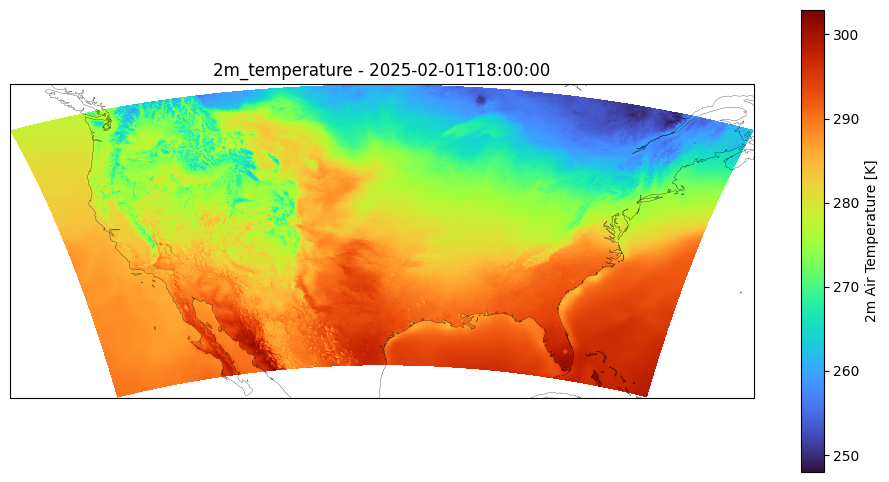

In [22]:
var_to_plot = "2m_temperature"  # can change to meridional wind or precipitation.
time_to_plot = "2025-02-01T18:00:00"  # can change to a different hour in your forecast.

field = (
    ds[var_to_plot]
    .sel(
        time=time_to_plot,
    )
    .squeeze()
)

fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

field.plot.pcolormesh(
    ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), cmap="turbo"
)

plt.title(f"{var_to_plot} - {time_to_plot}")

ax.coastlines(linewidth=0.2)
plt.show()

Plot a pressure level

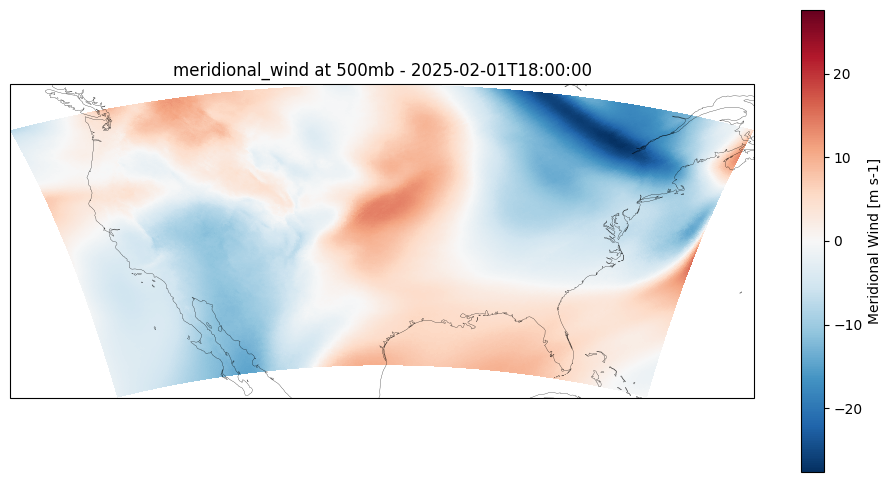

In [23]:
var_to_plot = "meridional_wind"  # can change to meridional wind or precipitation.
time_to_plot = "2025-02-01T18:00:00"  # can change to a different hour in your forecast.

field = (
    ds[var_to_plot]
    .sel(
        time=time_to_plot,
    )
    .squeeze()
)

fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

field.plot.pcolormesh(
    ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), cmap="RdBu_r"
)

plt.title(f"{var_to_plot} at {level_to_load}mb - {time_to_plot}")

ax.coastlines(linewidth=0.2)
plt.show()

Create a Dask-backed GIF of an atmospheric river event with GeoGIF

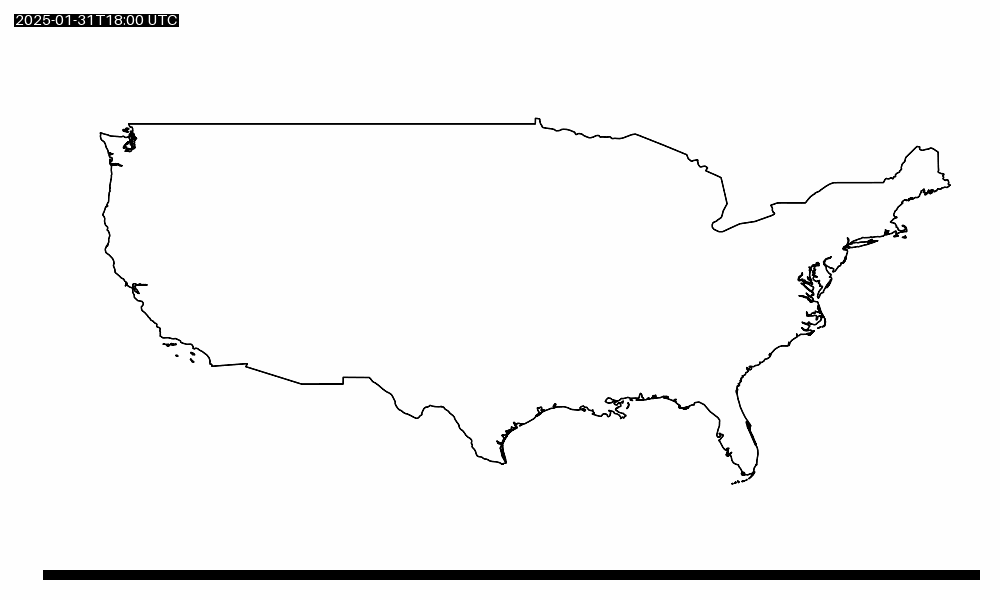

In [24]:
var_to_plot = "total_precipitation_6hr"

field = ds[var_to_plot]
gif_title = f"nested-EAGLE CONUS forecast initialized {init_to_plot:%Y-%m-%d %HZ}"
scale_label = f"{field.attrs['long_name']} ({field.attrs['units']})"


def add_progress_bar(image, frame_index, frame_count):
    height, width, _ = image.shape
    margin = max(8, width // 50)
    bar_height = max(6, height // 60)
    y_start = height - margin - bar_height
    x_start, x_stop = margin, width - margin
    fill_stop = x_start + round((x_stop - x_start) * (frame_index + 1) / frame_count)
    bar_rows = slice(y_start, y_start + bar_height)
    image[bar_rows, slice(x_start, x_stop)] = (30, 30, 30)
    image[bar_rows, slice(x_start, fill_stop)] = (255, 255, 255)
    return image


countries = shpreader.Reader(
    shpreader.natural_earth(
        resolution="50m",
        category="cultural",
        name="admin_0_countries",
    )
)
united_states = next(
    record.geometry
    for record in countries.records()
    if record.attributes["ADMIN"] == "United States of America"
)

frames = []
for frame_index, frame in enumerate(field):
    fig = Figure(figsize=(10, 6), dpi=100)
    FigureCanvasAgg(fig)
    ax = fig.add_subplot(projection=ccrs.PlateCarree())
    mesh = ax.pcolormesh(
        ds.lon,
        ds.lat,
        frame,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="gist_ncar_r",
        vmin=0,
        vmax=30,
    )
    ax.set_title(gif_title, fontsize=14)
    colorbar = fig.colorbar(
        mesh,
        ax=ax,
        orientation="horizontal",
        pad=0.03,
        shrink=0.75,
    )
    colorbar.set_label(scale_label)
    ax.add_geometries(
        [united_states],
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=1,
    )
    ax.set_extent(
        [
            float(ds.lon.min()),
            float(ds.lon.max()),
            float(ds.lat.min()),
            float(ds.lat.max()),
        ],
        crs=ccrs.PlateCarree(),
    )
    ax.set_axis_off()
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.08, top=0.92)
    fig.canvas.draw()
    image = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    frames.append(add_progress_bar(image, frame_index, field.sizes["time"]))

rgb_frames = xr.DataArray(
    np.stack(frames).transpose(0, 3, 1, 2),
    dims=("time", "band", "y", "x"),
    coords={"time": field.time, "band": ["red", "green", "blue"]},
).chunk({"time": 1})

geogif.dgif(
    rgb_frames,
    fps=4,
    date_format="%Y-%m-%dT%H:%M UTC",
).compute()